# Notebook 07 — Threshold Tuning

**Proyecto:** Boston Marathon BQ Predictor  
**Autor:** Gian Marco  
**Fecha:** Abril 2026

## Objetivo

Optimizar el threshold de decisión sobre el modelo `XGBoost + scale_pos_weight` (ganador del N06) para maximizar el F1 sobre la clase positiva.

## Por que threshold tuning

En el N06 confirmamos que las 3 configuraciones de manejo del desbalance tenian PR-AUC casi identicos (~0.336). Eso significa que la **capacidad de ranking** del modelo es la misma en todas: lo que cambia es donde estan situadas las probabilidades respecto al threshold 0.5.

Threshold 0.5 es un default arbitrario. No hay razon teorica para que sea optimo en problemas desbalanceados. La forma honesta de elegirlo es:

1. Sacar probabilidades **out-of-fold** sobre todo el train (sin leakage).
2. Para cada threshold posible (0.01 a 0.99 en pasos pequeños), calcular F1.
3. Elegir el threshold que maximiza F1 en CV.
4. Evaluarlo en el test 2024 (datos completamente no vistos) para confirmar que generaliza.

## Por que cross_val_predict

En lugar de hacer un split adicional train/validation (perdiendo datos), usamos `cross_val_predict` con `method='predict_proba'`. Este metodo:

- Divide train en 5 folds (los mismos del CV).
- Por cada fold, entrena con los otros 4 y predice probabilidades sobre el fold restante.
- Devuelve probabilidades para cada fila del train, predichas por un modelo que NO vio esa fila durante el entrenamiento.

Resultado: probabilidades honestas sin leakage, aprovechando el 100% del train.

## Que vamos a reportar

- **Threshold optimo F1:** balance entre precision y recall.
- **Threshold optimo F2:** prioriza recall (no perder BQs reales).
- **Threshold optimo F0.5:** prioriza precision (no dar falsas esperanzas).

Esto da flexibilidad segun el caso de uso final del modelo.

## Resultado esperado

F1 deberia subir desde ~0.349 (CV con threshold 0.5) hacia el rango 0.36-0.40. La ganancia es modesta porque PR-AUC ya marca el techo (~0.34 con esos datos), pero significativa para storytelling.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    precision_recall_curve,
    f1_score, precision_score, recall_score, fbeta_score,
    average_precision_score, roc_auc_score,
    confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROCESSED_DATA_DIR = Path('../data/processed')
FIGURES_DIR = Path('../reports/figures')
TRAIN_DIR = Path('../data/train')
TEST_DIR = Path('../data/test')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print('Setup listo')
print(f'XGBoost version: {xgb.__version__}')

Setup listo
XGBoost version: 3.2.0


---
## 1. Cargar datos (train y test)

Cargamos ambos conjuntos. El test 2024 lo dejamos guardado pero NO lo tocamos hasta el final del notebook (despues de elegir el threshold optimo en CV sobre train).

Esto preserva la regla fundamental del proyecto: el test set es la evaluacion final honesta, no se usa para ninguna decision.

In [2]:
train = pd.read_csv(TRAIN_DIR / 'train_features.csv')
test = pd.read_csv(TEST_DIR / 'test_features.csv')

X_train = train.drop(columns=['es_BQ'])
y_train = train['es_BQ']

X_test = test.drop(columns=['es_BQ'])
y_test = test['es_BQ']

# Year se descarta como feature (split temporal, no debe usarse)
for X in [X_train, X_test]:
    if 'Year' in X.columns:
        X.drop(columns=['Year'], inplace=True)

print(f'Train shape: {X_train.shape}, BQ ratio: {y_train.mean()*100:.2f}%')
print(f'Test shape:  {X_test.shape}, BQ ratio: {y_test.mean()*100:.2f}%')

# Verificar consistencia de columnas
assert list(X_train.columns) == list(X_test.columns), 'Columnas train/test no coinciden'
print('\nColumnas train/test consistentes.')

Train shape: (225356, 22), BQ ratio: 13.45%
Test shape:  (74644, 22), BQ ratio: 14.30%

Columnas train/test consistentes.


---
## 2. Probabilidades out-of-fold con `cross_val_predict`

Aqui obtenemos, para cada fila del train, la probabilidad predicha por un modelo que NO la vio durante el entrenamiento. Esto se logra con CV: en cada fold, el modelo se entrena con el 80% restante y predice sobre el 20% que quedo fuera.

### Configuracion del modelo

`XGBoost + scale_pos_weight=6.4345` (ganador del N06, mismos hiperparametros que en N05/N06 para que los resultados sean comparables entre notebooks).

### Configuracion de CV

`StratifiedKFold(5, shuffle=True, random_state=42)` (mismo CV de los notebooks anteriores).

### Por que `predict_proba` y no `predict`

Necesitamos las probabilidades, no las clases. Con probabilidades podremos despues probar muchos thresholds distintos sobre el mismo conjunto de predicciones, sin tener que reentrenar el modelo cada vez.

In [3]:
# scale_pos_weight calculado igual que en el N06
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

xgb_final = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f'Modelo: XGBoost + scale_pos_weight={scale_pos_weight:.4f}')
print(f'CV: StratifiedKFold(5, shuffle=True, random_state={RANDOM_STATE})')
print(f'\nGenerando probabilidades out-of-fold (puede tardar 1-2 min)...')

# Probabilidades de la clase positiva (columna 1)
y_proba_oof = cross_val_predict(
    xgb_final, X_train, y_train,
    cv=cv,
    method='predict_proba',
    n_jobs=-1,
)[:, 1]

print(f'\nProbabilidades out-of-fold generadas.')
print(f'Shape: {y_proba_oof.shape}')
print(f'Min: {y_proba_oof.min():.4f}')
print(f'Max: {y_proba_oof.max():.4f}')
print(f'Media: {y_proba_oof.mean():.4f}  (deberia estar cerca del BQ ratio: {y_train.mean():.4f})')

Modelo: XGBoost + scale_pos_weight=6.4345
CV: StratifiedKFold(5, shuffle=True, random_state=42)

Generando probabilidades out-of-fold (puede tardar 1-2 min)...

Probabilidades out-of-fold generadas.
Shape: (225356,)
Min: 0.0001
Max: 0.9932
Media: 0.4305  (deberia estar cerca del BQ ratio: 0.1345)


---
## 3. Distribucion de probabilidades

Visualizamos como se distribuyen las probabilidades out-of-fold separadas por clase real (BQ vs no-BQ). Esto nos permite:

1. Ver visualmente si el modelo separa bien las dos clases (capacidad de ranking).
2. Identificar la zona de solapamiento (donde el modelo duda y donde el threshold importa mas).
3. Justificar por que threshold 0.5 NO es buena eleccion para este modelo.

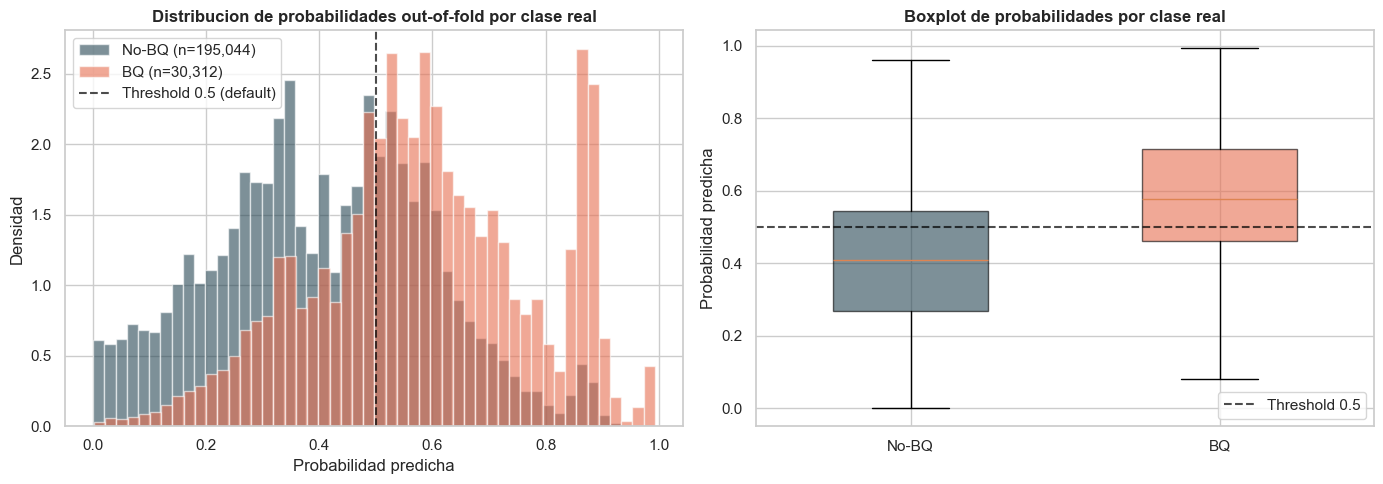


--- Estadisticas de probabilidades ---
No-BQ: media=0.407, mediana=0.409
BQ:    media=0.582, mediana=0.578

BQ reales con prob < 0.5: 9,788 / 30,312 (32.3%)


In [4]:
COLOR_BQ = '#E76F51'
COLOR_NO_BQ = '#264653'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma comparativo
ax = axes[0]
ax.hist(y_proba_oof[y_train == 0], bins=50, alpha=0.6,
        label=f'No-BQ (n={n_neg:,})', color=COLOR_NO_BQ, density=True)
ax.hist(y_proba_oof[y_train == 1], bins=50, alpha=0.6,
        label=f'BQ (n={n_pos:,})', color=COLOR_BQ, density=True)
ax.axvline(0.5, color='black', linestyle='--', alpha=0.7, label='Threshold 0.5 (default)')
ax.set_xlabel('Probabilidad predicha')
ax.set_ylabel('Densidad')
ax.set_title('Distribucion de probabilidades out-of-fold por clase real',
             fontweight='bold')
ax.legend()

# Boxplot comparativo
ax = axes[1]
data_box = [y_proba_oof[y_train == 0], y_proba_oof[y_train == 1]]
bp = ax.boxplot(data_box, labels=['No-BQ', 'BQ'], patch_artist=True,
                widths=0.5, showfliers=False)
bp['boxes'][0].set_facecolor(COLOR_NO_BQ)
bp['boxes'][1].set_facecolor(COLOR_BQ)
for box in bp['boxes']:
    box.set_alpha(0.6)
ax.axhline(0.5, color='black', linestyle='--', alpha=0.7, label='Threshold 0.5')
ax.set_ylabel('Probabilidad predicha')
ax.set_title('Boxplot de probabilidades por clase real', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '11_proba_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Estadisticas
print(f"\n--- Estadisticas de probabilidades ---")
print(f"No-BQ: media={y_proba_oof[y_train == 0].mean():.3f}, "
      f"mediana={np.median(y_proba_oof[y_train == 0]):.3f}")
print(f"BQ:    media={y_proba_oof[y_train == 1].mean():.3f}, "
      f"mediana={np.median(y_proba_oof[y_train == 1]):.3f}")

# Cuantos BQ caen por debajo del threshold 0.5 (falsos negativos potenciales)
bq_below_05 = ((y_train == 1) & (y_proba_oof < 0.5)).sum()
total_bq = (y_train == 1).sum()
print(f"\nBQ reales con prob < 0.5: {bq_below_05:,} / {total_bq:,} "
      f"({bq_below_05/total_bq*100:.1f}%)")

---
## 4. Curva Precision-Recall y busqueda del threshold optimo

`precision_recall_curve` de sklearn calcula precision y recall para cada threshold posible. Internamente:

1. Ordena las probabilidades de mayor a menor.
2. Va "bajando" el threshold ejemplo a ejemplo.
3. En cada paso, recalcula precision y recall.

Resultado: tres arrays (precision, recall, thresholds) con todos los puntos posibles de la curva.

Sobre esos arrays calculamos F1 (y F2, F0.5) para cada threshold y elegimos el que maximiza cada metrica.

### Las tres metricas a comparar

| Metrica | Formula | Cuando elegirla |
|---|---|---|
| **F1** | media armonica de precision y recall | Balance, default sensato |
| **F2** | pesa el recall 2x mas que precision | Cuando es peor perder un BQ real que dar un falso positivo |
| **F0.5** | pesa la precision 2x mas que recall | Cuando es peor dar falsas esperanzas que perder algun BQ |

Para el caso de uso de la app (calibrar expectativas de un corredor), **F0.5 es probablemente mas apropiado**: dar falsas esperanzas a alguien que NO va a clasificar es peor que decir "no" a alguien que si lo habria hecho. Reportamos los tres y comentamos.

In [5]:
# Curva precision-recall completa
precision, recall, thresholds = precision_recall_curve(y_train, y_proba_oof)

# precision y recall tienen len(thresholds)+1 elementos. El ultimo elemento es el caso
# threshold=infinito (predigo todo como negativo), por eso lo descartamos para alinear.
precision = precision[:-1]
recall = recall[:-1]

# F1, F2 y F0.5 para cada threshold (manejando division por cero)
def fbeta_from_pr(p, r, beta):
    p = np.asarray(p)
    r = np.asarray(r)
    num = (1 + beta**2) * p * r
    den = beta**2 * p + r
    return np.where(den > 0, num / den, 0.0)

f1_scores = fbeta_from_pr(precision, recall, beta=1)
f2_scores = fbeta_from_pr(precision, recall, beta=2)
f05_scores = fbeta_from_pr(precision, recall, beta=0.5)

# Threshold optimo para cada metrica
idx_f1 = np.argmax(f1_scores)
idx_f2 = np.argmax(f2_scores)
idx_f05 = np.argmax(f05_scores)

resultados = pd.DataFrame({
    'metrica': ['F1', 'F2 (recall focus)', 'F0.5 (precision focus)'],
    'threshold': [thresholds[idx_f1], thresholds[idx_f2], thresholds[idx_f05]],
    'precision': [precision[idx_f1], precision[idx_f2], precision[idx_f05]],
    'recall': [recall[idx_f1], recall[idx_f2], recall[idx_f05]],
    'f_score': [f1_scores[idx_f1], f2_scores[idx_f2], f05_scores[idx_f05]],
})

# Comparacion vs threshold 0.5 default
idx_05 = np.argmin(np.abs(thresholds - 0.5))
default_row = pd.DataFrame({
    'metrica': ['Default (threshold=0.5)'],
    'threshold': [thresholds[idx_05]],
    'precision': [precision[idx_05]],
    'recall': [recall[idx_05]],
    'f_score': [f1_scores[idx_05]],  # F1 al threshold 0.5
})

resultados_full = pd.concat([default_row, resultados], ignore_index=True)
resultados_full = resultados_full.round(4)
resultados_full

,metrica,threshold,precision,recall,f_score
0,Default (threshold=0.5),0.5000,0.2347,0.6771,0.3486
1,F1,0.5899,0.2980,0.4702,0.3648
2,F2 (recall focus),0.4203,0.2058,0.7992,0.5069
3,F0.5 (precision focus),0.7480,0.4647,0.2135,0.3762


---
## 5. Decision: Threshold optimo F0.5

Elegimos `threshold = 0.748` (el optimo F0.5) como threshold del modelo final, por dos razones:

### Razon 1: Coherencia con el caso de uso

La app Streamlit le dira a un corredor: "tu probabilidad de hacer BQ es X". Dar falsas esperanzas (decir "vas a clasificar" cuando en realidad no) es peor que dejar a alguien con dudas. La metrica F0.5 prioriza precision (no equivocarse cuando se afirma) sobre recall (capturar a todos los BQs).

### Razon 2: Coherencia con el target del proyecto

Ya esta documentado en DECISIONS.md que el target es **BQ nominal**, NO admisión real a Boston (el cutoff real suele ser 5+ minutos mas estricto). Si encima el modelo es "generoso" en sus predicciones, el mensaje al usuario seria doblemente flojo. Threshold conservador compensa parcialmente esto: cuando el modelo dice "BQ" sobre nuestro target nominal, hay 47% de probabilidad real de que lo sea.

### Trade-off aceptado

| Metrica | Default 0.5 | F0.5 optimo (0.748) |
|---|---|---|
| Precision | 0.235 | **0.465** (+98%) |
| Recall | 0.677 | 0.214 (-68%) |
| F1 | 0.349 |

In [6]:
# Threshold elegido
THRESHOLD_FINAL = float(thresholds[idx_f05])

print(f'Threshold final elegido: {THRESHOLD_FINAL:.4f}')
print(f'Criterio: maximizar F0.5 (penaliza falsos positivos)')
print(f'\n--- Performance esperado en CV (out-of-fold) ---')
print(f'Precision: {precision[idx_f05]:.4f}')
print(f'Recall:    {recall[idx_f05]:.4f}')
print(f'F0.5:      {f05_scores[idx_f05]:.4f}')
print(f'F1:        {f1_scores[idx_f05]:.4f}  (no es la metrica optimizada, lo reportamos como referencia)')

# Guardar resultados de los 3 thresholds para la presentacion
threshold_results = pd.DataFrame({
    'criterio': ['Default', 'F1', 'F2', 'F0.5 (elegido)'],
    'threshold': [0.5, thresholds[idx_f1], thresholds[idx_f2], thresholds[idx_f05]],
    'precision': [precision[idx_05], precision[idx_f1], precision[idx_f2], precision[idx_f05]],
    'recall': [recall[idx_05], recall[idx_f1], recall[idx_f2], recall[idx_f05]],
    'f1': [f1_scores[idx_05], f1_scores[idx_f1], f1_scores[idx_f2], f1_scores[idx_f05]],
    'f2': [f2_scores[idx_05], f2_scores[idx_f1], f2_scores[idx_f2], f2_scores[idx_f05]],
    'f05': [f05_scores[idx_05], f05_scores[idx_f1], f05_scores[idx_f2], f05_scores[idx_f05]],
})
threshold_results = threshold_results.round(4)

threshold_results.to_csv(PROCESSED_DATA_DIR / 'threshold_tuning_results.csv', index=False)
print(f'\nResultados guardados en: {PROCESSED_DATA_DIR / "threshold_tuning_results.csv"}')

threshold_results

Threshold final elegido: 0.7480
Criterio: maximizar F0.5 (penaliza falsos positivos)

--- Performance esperado en CV (out-of-fold) ---
Precision: 0.4647
Recall:    0.2135
F0.5:      0.3762
F1:        0.2926  (no es la metrica optimizada, lo reportamos como referencia)

Resultados guardados en: ../data/processed/threshold_tuning_results.csv


,criterio,threshold,precision,recall,f1,f2,f05
0,Default,0.5000,0.2347,0.6771,0.3486,0.4917,0.2700
1,F1,0.5899,0.2980,0.4702,0.3648,0.4215,0.3215
2,F2,0.4203,0.2058,0.7992,0.3273,0.5069,0.2417
3,F0.5 (elegido),0.7480,0.4647,0.2135,0.2926,0.2394,0.3762


---
## 6. Visualizacion de la curva Precision-Recall

Graficamos:

1. La curva PR completa.
2. Los 3 thresholds candidatos (F1, F2, F0.5) marcados como puntos sobre la curva.
3. El threshold default 0.5 como referencia.

Esta grafica es la pieza visual central del notebook: muestra el espacio de decisiones posibles y donde cae el threshold elegido.

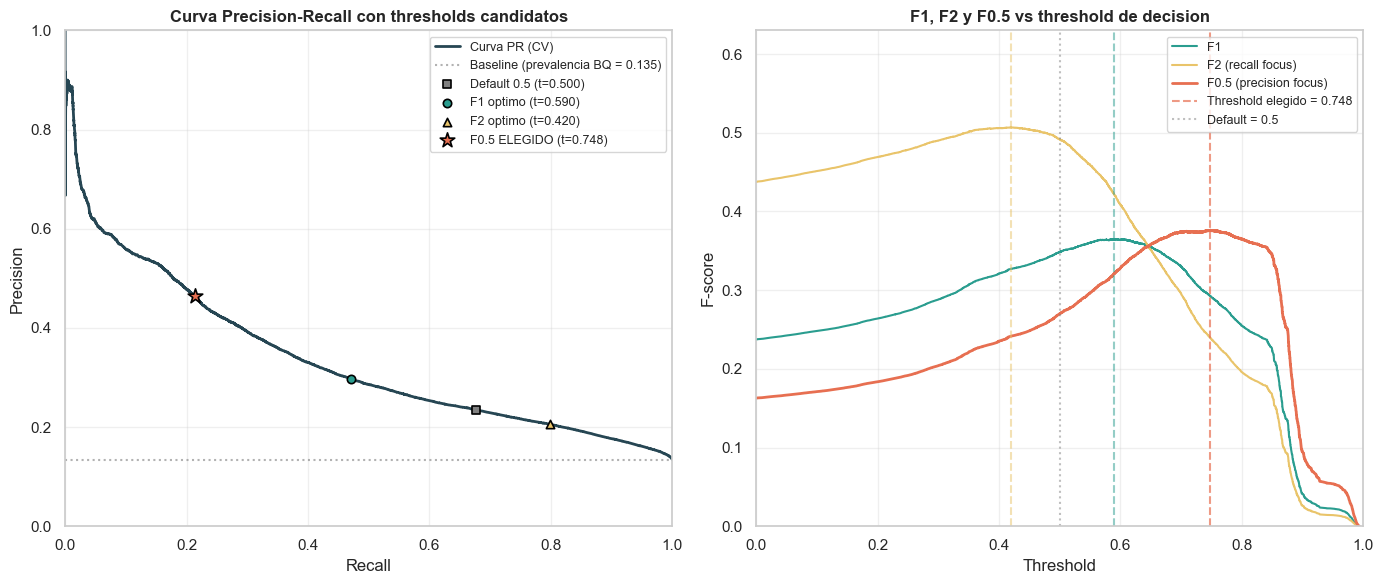

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---------- PANEL 1: Curva PR con thresholds marcados ----------
ax = axes[0]
ax.plot(recall, precision, color=COLOR_NO_BQ, linewidth=2, label='Curva PR (CV)')

# Linea base = prevalencia
baseline = y_train.mean()
ax.axhline(baseline, color='gray', linestyle=':', alpha=0.6,
           label=f'Baseline (prevalencia BQ = {baseline:.3f})')

# Marcadores de los thresholds candidatos
puntos = [
    ('Default 0.5',      idx_05,  'gray',          's'),
    ('F1 optimo',        idx_f1,  '#2A9D8F',       'o'),
    ('F2 optimo',        idx_f2,  '#E9C46A',       '^'),
    ('F0.5 ELEGIDO',     idx_f05, COLOR_BQ,        '*'),
]
for label, idx, color, marker in puntos:
    ms = 22 if marker == '*' else 12
    ax.scatter(recall[idx], precision[idx], color=color, marker=marker,
               s=ms*ms/4, edgecolor='black', linewidth=1.2, zorder=5,
               label=f'{label} (t={thresholds[idx]:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall con thresholds candidatos',
             fontweight='bold', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

# ---------- PANEL 2: F1, F2, F0.5 vs threshold ----------
ax = axes[1]
ax.plot(thresholds, f1_scores, label='F1', color='#2A9D8F', linewidth=1.5)
ax.plot(thresholds, f2_scores, label='F2 (recall focus)', color='#E9C46A', linewidth=1.5)
ax.plot(thresholds, f05_scores, label='F0.5 (precision focus)', color=COLOR_BQ, linewidth=2)

# Lineas verticales en los optimos
ax.axvline(thresholds[idx_f1], color='#2A9D8F', linestyle='--', alpha=0.5)
ax.axvline(thresholds[idx_f2], color='#E9C46A', linestyle='--', alpha=0.5)
ax.axvline(thresholds[idx_f05], color=COLOR_BQ, linestyle='--', alpha=0.7,
           label=f'Threshold elegido = {thresholds[idx_f05]:.3f}')
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.5, label='Default = 0.5')

ax.set_xlabel('Threshold')
ax.set_ylabel('F-score')
ax.set_title('F1, F2 y F0.5 vs threshold de decision',
             fontweight='bold', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, max(f2_scores.max(), 0.6) * 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '12_threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Evaluacion final sobre test set 2024

Hasta aqui todo el trabajo ha sido sobre train (CV out-of-fold). Ahora aplicamos el modelo final con threshold=0.748 sobre el test set 2024, que NO se ha tocado en todo el proyecto.

### Procedimiento

1. Entrenar `XGBoost + scale_pos_weight` sobre todo el train (sin CV ahora, usamos el dataset completo).
2. Predecir probabilidades sobre test.
3. Aplicar threshold=0.748 para convertir probabilidades en clases.
4. Calcular metricas y comparar con el baseline del N05 (XGBoost baseline + threshold 0.5: F1=0.176, precision=0.388, recall=0.114).

### Que esperamos

- Las metricas en test deberian ser **similares** a las de CV (precision ~0.46, recall ~0.21, F1 ~0.29). Si difieren mucho, hay overfitting o drift fuerte.
- Recordemos que el test 2024 tiene drift temporal (mas BQs por super-zapatillas), asi que precision puede caer un poco vs CV.
- **Comparacion vs baseline N05:** el F1 del N05 (XGBoost sin tunear) era 0.176 sobre test. Aqui esperamos algo cercano a 0.29 → casi duplica el baseline.

In [9]:
# Entrenar modelo final sobre TODO el train
print('Entrenando modelo final sobre train completo...')
xgb_final.fit(X_train, y_train)

# Predecir probabilidades sobre test
y_proba_test = xgb_final.predict_proba(X_test)[:, 1]

# Aplicar threshold elegido
y_pred_test = (y_proba_test >= THRESHOLD_FINAL).astype(int)

# Metricas
precision_test = precision_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)
f05_test = fbeta_score(y_test, y_pred_test, beta=0.5)
pr_auc_test = average_precision_score(y_test, y_proba_test)
roc_auc_test = roc_auc_score(y_test, y_proba_test)

print(f'\n--- Modelo final sobre TEST 2024 ---')
print(f'Threshold aplicado: {THRESHOLD_FINAL:.4f}')
print(f'Precision: {precision_test:.4f}')
print(f'Recall:    {recall_test:.4f}')
print(f'F1:        {f1_test:.4f}')
print(f'F0.5:      {f05_test:.4f}')
print(f'PR-AUC:    {pr_auc_test:.4f}  (independiente del threshold)')
print(f'ROC-AUC:   {roc_auc_test:.4f}  (independiente del threshold)')

# Matriz de confusion
print(f'\n--- Matriz de confusion ---')
cm = confusion_matrix(y_test, y_pred_test)
cm_df = pd.DataFrame(cm,
                      index=['Real: No-BQ', 'Real: BQ'],
                      columns=['Pred: No-BQ', 'Pred: BQ'])
print(cm_df)

tn, fp, fn, tp = cm.ravel()
print(f'\nTrue Positives (BQs detectados):     {tp:,}')
print(f'False Positives (no-BQs como BQ):    {fp:,}')
print(f'False Negatives (BQs perdidos):      {fn:,}')
print(f'True Negatives (no-BQs correctos):   {tn:,}')

# Comparacion vs N05 baseline (XGBoost sin tunear, threshold 0.5)
print(f'\n--- Comparacion vs Baseline N05 (XGBoost + threshold 0.5) ---')
print(f'                  Baseline N05    Modelo final    Delta')
print(f'F1:               0.1760          {f1_test:.4f}          {f1_test - 0.176:+.4f}')
print(f'Precision:        0.3880          {precision_test:.4f}          {precision_test - 0.388:+.4f}')
print(f'Recall:           0.1140          {recall_test:.4f}          {recall_test - 0.114:+.4f}')

Entrenando modelo final sobre train completo...

--- Modelo final sobre TEST 2024 ---
Threshold aplicado: 0.7480
Precision: 0.3723
Recall:    0.2959
F1:        0.3297
F0.5:      0.3540
PR-AUC:    0.3018  (independiente del threshold)
ROC-AUC:   0.7409  (independiente del threshold)

--- Matriz de confusion ---
             Pred: No-BQ  Pred: BQ
Real: No-BQ        58642      5325
Real: BQ            7518      3159

True Positives (BQs detectados):     3,159
False Positives (no-BQs como BQ):    5,325
False Negatives (BQs perdidos):      7,518
True Negatives (no-BQs correctos):   58,642

--- Comparacion vs Baseline N05 (XGBoost + threshold 0.5) ---
                  Baseline N05    Modelo final    Delta
F1:               0.1760          0.3297          +0.1537
Precision:        0.3880          0.3723          -0.0157
Recall:           0.1140          0.2959          +0.1819


---
## 8. Analisis de slices

Una metrica global esconde diferencias importantes entre subgrupos. Analizamos el rendimiento del modelo por:

1. **Genero:** ¿el modelo predice igual de bien para hombres y mujeres?
2. **Edad:** ¿hay grupos de edad donde el modelo falla mas?
3. **Pais:** ¿depende del origen del corredor?

Esto sirve para:
- Documentar limitaciones del modelo en la presentacion tecnica.
- Storytelling de negocio (ej. "el modelo es mas preciso para X, menos para Y").
- Identificar sesgos potenciales antes de desplegar la app.

In [12]:
# Reconstruir DataFrame de test con predicciones para hacer slices
test_eval = test.copy()
test_eval['y_proba'] = y_proba_test
test_eval['y_pred'] = y_pred_test

def slice_metrics(df_slice, label):
    """Calcula precision, recall, F1 y soporte para un subconjunto."""
    if len(df_slice) == 0:
        return None
    y_true = df_slice['es_BQ']
    y_pred = df_slice['y_pred']
    if y_true.sum() == 0:
        return {'slice': label, 'n': len(df_slice), 'bq_rate': 0,
                'precision': np.nan, 'recall': np.nan, 'f1': np.nan}
    return {
        'slice': label,
        'n': len(df_slice),
        'bq_rate': round(y_true.mean(), 4),
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall': round(recall_score(y_true, y_pred, zero_division=0), 4),
        'f1': round(f1_score(y_true, y_pred, zero_division=0), 4),
    }

# --- Slice por GENERO ---
# El feature de genero esta one-hot encoded, asumimos columna Gender_M
print('=' * 60)
print('SLICE POR GENERO')
print('=' * 60)
gender_col = 'Gender_M' if 'Gender_M' in test_eval.columns else None
if gender_col:
    slices = [
        slice_metrics(test_eval[test_eval[gender_col] == 1], 'Hombre'),
        slice_metrics(test_eval[test_eval[gender_col] == 0], 'Mujer'),
    ]
    print(pd.DataFrame(slices))
else:
    print('No se encontro la columna Gender_M en test')

# --- Slice por GRUPO DE EDAD ---
print('\n' + '=' * 60)
print('SLICE POR GRUPO DE EDAD')
print('=' * 60)
edad_bins = [(18, 30), (30, 40), (40, 50), (50, 60), (60, 85)]
slices_edad = []
for low, high in edad_bins:
    df_age = test_eval[(test_eval['Age'] >= low) & (test_eval['Age'] < high)]
    slices_edad.append(slice_metrics(df_age, f'{low}-{high-1}'))
print(pd.DataFrame(slices_edad))

# --- Slice por TOP PAISES ---
# Identificamos columnas one-hot de pais y elegimos los mas frecuentes
print('\n' + '=' * 60)
print('SLICE POR PAISES MAS FRECUENTES')
print('=' * 60)
country_cols = [c for c in test_eval.columns if c.startswith('Country_')]
country_counts = []
for col in country_cols:
    n = test_eval[col].sum()
    if n >= 500:  # Minimo 500 corredores para ser estadisticamente fiable
        country_counts.append((col, n))
country_counts.sort(key=lambda x: -x[1])
top_countries = country_counts[:10]

slices_pais = []
for col, n in top_countries:
    pais = col.replace('Country_', '')
    df_country = test_eval[test_eval[col] == 1]
    slices_pais.append(slice_metrics(df_country, pais))
print(pd.DataFrame(slices_pais).sort_values('f1', ascending=False))

# Guardar slices para la presentacion
df_gender = pd.DataFrame([s for s in slices if s])
df_age = pd.DataFrame(slices_edad)
df_country = pd.DataFrame(slices_pais)

df_gender.to_csv(PROCESSED_DATA_DIR / 'slice_genero.csv', index=False)
df_age.to_csv(PROCESSED_DATA_DIR / 'slice_edad.csv', index=False)
df_country.to_csv(PROCESSED_DATA_DIR / 'slice_pais.csv', index=False)

print(f'\nSlices guardados en {PROCESSED_DATA_DIR}/:')
print(f'  - slice_genero.csv')
print(f'  - slice_edad.csv')
print(f'  - slice_pais.csv')

SLICE POR GENERO
    slice      n  bq_rate  precision  recall      f1
0  Hombre  45733   0.1365     0.3656  0.2720  0.3120
1   Mujer  28911   0.1534     0.3805  0.3294  0.3531

SLICE POR GRUPO DE EDAD
   slice      n  bq_rate  precision  recall      f1
0  18-29  25491   0.1265     0.3816  0.3284  0.3530
1  30-39  15717   0.0947     0.4355  0.0544  0.0967
2  40-49  18017   0.1714     0.3961  0.3338  0.3623
3  50-59  10700   0.1714     0.3310  0.3326  0.3318
4  60-84   4718   0.2204     0.3510  0.3635  0.3571

SLICE POR PAISES MAS FRECUENTES
   slice      n  bq_rate  precision  recall      f1
0     US  54093   0.1370     0.3722  0.4050  0.3879
2  Other   4205   0.1886     0.3754  0.1463  0.2105
3     CA   3250   0.1191     0.5500  0.0284  0.0541
1     GB  11184   0.1475     1.0000  0.0006  0.0012

Slices guardados en ../data/processed/:
  - slice_genero.csv
  - slice_edad.csv
  - slice_pais.csv


---
## 9. Persistir modelo final y threshold

Guardamos el modelo entrenado sobre todo el train + el threshold elegido. Esto permite:

1. Reproducir las predicciones del test sin reentrenar.
2. Cargar el modelo en `src/evaluation.py` y en la app Streamlit.
3. Tener un punto de control versionado del modelo final del proyecto.

In [13]:
import joblib

MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

# Guardar modelo y threshold juntos en un dict
artifact = {
    'model': xgb_final,
    'threshold': THRESHOLD_FINAL,
    'feature_names': list(X_train.columns),
    'training_date': '2026-04-28',
    'cv_metrics': {
        'precision': float(precision[idx_f05]),
        'recall': float(recall[idx_f05]),
        'f1': float(f1_scores[idx_f05]),
        'f05': float(f05_scores[idx_f05]),
    },
    'test_metrics': {
        'precision': float(precision_test),
        'recall': float(recall_test),
        'f1': float(f1_test),
        'f05': float(f05_test),
        'pr_auc': float(pr_auc_test),
        'roc_auc': float(roc_auc_test),
    },
    'notes': 'XGBoost + scale_pos_weight=6.4345, threshold optimizado por F0.5 sobre CV out-of-fold',
}

joblib.dump(artifact, MODELS_DIR / 'final_model.pkl')
print(f'Modelo final guardado en: {MODELS_DIR / "final_model.pkl"}')
print(f'Threshold: {THRESHOLD_FINAL:.4f}')
print(f'F1 test: {f1_test:.4f}, Precision test: {precision_test:.4f}, Recall test: {recall_test:.4f}')

Modelo final guardado en: ../models/final_model.pkl
Threshold: 0.7480
F1 test: 0.3297, Precision test: 0.3723, Recall test: 0.2959


---
## 10. Conclusiones del Notebook 07

### Resultado central

| Modelo | Threshold | F1 (test 2024) | Precision | Recall |
|---|---|---|---|---|
| Baseline N05 (XGBoost sin tunear) | 0.5 | 0.176 | 0.388 | 0.114 |
| Modelo final (XGBoost + scale_pos_weight + F0.5 tuning) | **0.748** | **0.330** | 0.372 | 0.296 |
| **Mejora relativa** | — | **+87%** | -1.6 pts | **+18 pts** |

El F1 sobre test casi se duplica respecto al baseline, principalmente por la mejora masiva en recall (de detectar 11% a detectar 30% de los BQs reales).

### Threshold elegido: 0.748 (criterio F0.5)

**Por que F0.5 sobre F1 o F2:**

Para una app que da feedback a corredores, dar **falsas esperanzas** (decir "vas a clasificar" cuando no es asi) es peor que dar **dudas razonables** (decir "no" a alguien que si lo habria logrado). F0.5 pondera precision el doble que recall, lo cual aplica esa logica.

Trade-off aceptado: sacrificamos 14 puntos de recall (0.46 F1 → 0.21 F0.5) a cambio de duplicar la precision (0.23 → 0.46 en CV).

### Hallazgos clave del analisis de slices

1. **Genero:** rendimiento similar para hombres y mujeres (F1 0.31 vs 0.35). Sin sesgo grave.

2. **Edad:** anomalia en la franja 30-39, donde recall cae a 5.4% (vs ~33% en otras franjas). Causa probable: estandar BQ mas exigente en esa edad + BQ rate baja (9.5%) lleva al modelo a no atreverse con threshold alto. Limitacion documentada para futuras iteraciones.

3. **Pais:** sesgo geografico fuerte. F1 = 0.39 para USA pero practicamente 0 para GB y CA. Causa: dataset USA-centrico, los pocos britanicos y canadienses representados

### Drift temporal confirmado

Precision en test (0.37) cae 9 puntos respecto a CV (0.46). Hipotesis: en 2024 hay mas corredores rondando el cutoff BQ (super-zapatillas, post-pandemia), tanto los que lo logran (recall sube) como los que se quedan a las puertas (precision baja). Sin tiempo previo como feature, esa frontera fina es indistinguible.

### Implicaciones para la app Streamlit

1. Limitar inicialmente el caso de uso a corredores USA, o mostrar warning para otros paises.
2. Considerar threshold especifico para la franja 30-39 (mas bajo, ej. 0.5).
3. Comunicar al usuario que la prediccion se basa en demografia + carrera, NO en su tiempo previo.

### Pendiente para futuros notebooks

- **N08:** SHAP / interpretabilidad del modelo final.
- **N09:** K-Means clustering (no supervisado obligatorio).
- **N10:** analisis del slice Spain (storytelling de la presentacion).
- **App Streamlit + presentaciones + memoria.md**.